# 06 — Predicción de no-shows en reservas

**Objetivo:** predecir la probabilidad de que una reserva individual
termine en no-show, usando el histórico completo de reservas (Silver),
no solo el período con datos de ventas.

**Momento de predicción:** el día del servicio (overbooking operativo a
corto plazo). Esto determina qué variables son legítimas como feature y
cuáles constituyen leakage — ver auditoría en la Sección de feature
engineering.

**Universo de modelado:** reservas con desenlace resuelto sin ambigüedad
(`completada`, `no_show`), desde 2023-01-01, excluyendo el canal walk-in
(0 no-shows observados en ese canal — ver justificación cuantitativa más
abajo).

*Arquitectura Medallion: Bronze → Silver → **Gold***

### 0. Setup

Imports, rutas, carga de reservas (Silver, nivel individual) y de la
tabla maestra diaria (Gold, para variables de contexto del día de
servicio: meteorología, festivos, eventos).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_DIR    = PROJECT_ROOT / 'data'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'
GOLD_DIR    = DATA_DIR / 'gold'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'noshows'
MODELS_DIR  = PROJECT_ROOT / 'results' / 'models'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Silver snaps : {SILVER_SNAP}')
print(f'Gold dir     : {GOLD_DIR}')
print(f'Figures dir  : {FIGURES_DIR}')
print(f'Models dir   : {MODELS_DIR}')

Project root : /Users/laura/TFM-Hosteleria-AI
Silver snaps : /Users/laura/TFM-Hosteleria-AI/data/silver/snapshots
Gold dir     : /Users/laura/TFM-Hosteleria-AI/data/gold
Figures dir  : /Users/laura/TFM-Hosteleria-AI/results/figures/noshows
Models dir   : /Users/laura/TFM-Hosteleria-AI/results/models


In [2]:
# Reservas a nivel individual (Silver) — fuente principal del modelo.
# Ya incluye status_agrupado (5 categorías) y antelacion_horas persistida,
# ambas decididas y aplicadas en 02_depuracion_silver.
df_reservas = pd.read_parquet(SILVER_SNAP / 'reservas_silver.parquet')

# Tabla maestra diaria (Gold) — se usará más adelante para variables de
# contexto del día de servicio (meteo, festivo, evento), no para el
# universo de modelado en sí, que es a nivel de reserva individual, no
# de día agregado.
tabla_maestra_diaria = pd.read_parquet(GOLD_DIR / 'tabla_maestra_diaria.parquet')

print(f'Reservas (Silver)        : {df_reservas.shape}')
print(f'  Rango temporal         : {df_reservas["reservation_date"].min().date()} → '
      f'{df_reservas["reservation_date"].max().date()}')
print(f'  Columnas                : {df_reservas.columns.tolist()}')
print()
print(f'Tabla maestra diaria (Gold): {tabla_maestra_diaria.shape}')
print(f'  Rango temporal           : {tabla_maestra_diaria["fecha"].min().date()} → '
      f'{tabla_maestra_diaria["fecha"].max().date()}')

# Verificación de sanidad: confirmar que las columnas clave de la
# reclasificación de Silver están presentes antes de seguir.
assert 'status_agrupado' in df_reservas.columns, "Falta status_agrupado — revisa Silver"
assert 'antelacion_horas' in df_reservas.columns, "Falta antelacion_horas — revisa Silver"
assert set(df_reservas['status_agrupado'].unique()) == {
    'completada', 'cancelada', 'no_show', 'pendiente', 'liberada'
}, "Categorías de status_agrupado inesperadas — revisa si Silver se regeneró correctamente"

print("\n✓ Silver cargado con las 5 categorías esperadas y antelacion_horas presente")

Reservas (Silver)        : (21289, 21)
  Rango temporal         : 2022-11-10 → 2026-07-08
  Columnas                : ['source_file', 'reservation_datetime', 'created_datetime', 'reservation_date', 'reservation_time', 'status', 'shift', 'people', 'origin', 'created_date', 'created_time', 'restaurant', 'reservation_type', 'table', 'zone', 'group', 'reference_code', 'status_agrupado', 'es_walk_in', 'es_grupo_grande', 'antelacion_horas']

Tabla maestra diaria (Gold): (242, 37)
  Rango temporal           : 2025-10-02 → 2026-07-09

✓ Silver cargado con las 5 categorías esperadas y antelacion_horas presente


### 1. Definición del universo de modelado

Se aplican tres filtros secuenciales sobre `df_reservas`, cada uno con
conteo explícito de filas incluidas/excluidas y su motivo:

1. **Desenlace resuelto sin ambigüedad**: `status_agrupado ∈ {completada, no_show}`.
   Se excluyen `cancelada` (desenlace distinto al que modela este target),
   `pendiente` (desenlace aún no conocido) y `liberada` (desenlace
   ambiguo, ver justificación en `02_depuracion_silver`).
2. **Corte temporal**: `reservation_date >= 2023-01-01`. Se excluye 2022
   por ser un año parcial de bajo volumen (721 filas de 21.289, ~3.4%).
3. **Exclusión de walk-in**: `origin != 'walk in'`. Justificación
   cuantitativa: dentro de walk-in, la tasa de no-show observada es 0%
   (verificado más abajo con los datos ya corregidos de Silver, no
   asumido del análisis exploratorio previo).

In [3]:
n_inicial = len(df_reservas)
print(f"Reservas totales en Silver: {n_inicial}\n")

# ── Filtro 1: desenlace resuelto sin ambigüedad ─────────────────────────
conteo_status = df_reservas['status_agrupado'].value_counts()
print("Distribución completa por status_agrupado:")
print(conteo_status.to_string())
print()

universo = df_reservas[df_reservas['status_agrupado'].isin(['completada', 'no_show'])].copy()
n_tras_filtro1 = len(universo)
print(f"Filtro 1 (completada + no_show): {n_tras_filtro1} filas "
      f"({n_inicial - n_tras_filtro1} excluidas)")
print(f"  - cancelada excluidas : {conteo_status.get('cancelada', 0)}")
print(f"  - pendiente excluidas : {conteo_status.get('pendiente', 0)}")
print(f"  - liberada excluidas  : {conteo_status.get('liberada', 0)}")
print()

# ── Filtro 2: corte temporal ─────────────────────────────────────────────
FECHA_INICIO_MODELO = pd.Timestamp('2023-01-01')
n_2022 = (universo['reservation_date'] < FECHA_INICIO_MODELO).sum()

universo = universo[universo['reservation_date'] >= FECHA_INICIO_MODELO].copy()
n_tras_filtro2 = len(universo)
print(f"Filtro 2 (desde {FECHA_INICIO_MODELO.date()}): {n_tras_filtro2} filas "
      f"({n_2022} excluidas, año 2022 parcial)")
print()

# ── Verificación cuantitativa antes del filtro 3: tasa de no-show en walk-in ──
tasa_noshow_walkin = (
    universo[universo['origin'] == 'walk in']['status_agrupado']
    .eq('no_show')
    .mean()
)
n_walkin = (universo['origin'] == 'walk in').sum()
print(f"Tasa de no-show dentro de walk-in: {tasa_noshow_walkin:.4f} "
      f"(sobre {n_walkin} reservas walk-in en el universo tras filtros 1-2)")

if tasa_noshow_walkin > 0:
    print("⚠️  ALERTA: hay no-shows dentro de walk-in — revisar antes de excluir el canal, "
          "la justificación cuantitativa ya no se sostiene tal cual.")
print()

# ── Filtro 3: exclusión de walk-in ───────────────────────────────────────
n_walkin_excluidas = (universo['origin'] == 'walk in').sum()

universo = universo[universo['origin'] != 'walk in'].copy()
n_tras_filtro3 = len(universo)
print(f"Filtro 3 (excluir walk-in): {n_tras_filtro3} filas "
      f"({n_walkin_excluidas} excluidas)")
print()

# ── Resumen del embudo completo ──────────────────────────────────────────
print("="*60)
print("RESUMEN DEL EMBUDO DE FILTRADO")
print("="*60)
print(f"{'Reservas totales (Silver)':<45} {n_inicial:>8}")
print(f"{'Tras filtro 1 (desenlace resuelto)':<45} {n_tras_filtro1:>8}")
print(f"{'Tras filtro 2 (desde 2023-01-01)':<45} {n_tras_filtro2:>8}")
print(f"{'Tras filtro 3 (sin walk-in)':<45} {n_tras_filtro3:>8}")
print(f"{'% del total original':<45} {n_tras_filtro3/n_inicial*100:>7.1f}%")

Reservas totales en Silver: 21289

Distribución completa por status_agrupado:
status_agrupado
completada    17243
cancelada      2886
liberada        662
no_show         493
pendiente         5

Filtro 1 (completada + no_show): 17736 filas (3553 excluidas)
  - cancelada excluidas : 2886
  - pendiente excluidas : 5
  - liberada excluidas  : 662

Filtro 2 (desde 2023-01-01): 17259 filas (477 excluidas, año 2022 parcial)

Tasa de no-show dentro de walk-in: 0.0000 (sobre 2840 reservas walk-in en el universo tras filtros 1-2)

Filtro 3 (excluir walk-in): 14419 filas (2840 excluidas)

RESUMEN DEL EMBUDO DE FILTRADO
Reservas totales (Silver)                        21289
Tras filtro 1 (desenlace resuelto)               17736
Tras filtro 2 (desde 2023-01-01)                 17259
Tras filtro 3 (sin walk-in)                      14419
% del total original                             67.7%


In [4]:
universo['es_no_show'] = (universo['status_agrupado'] == 'no_show').astype(int)

n_no_show = universo['es_no_show'].sum()
n_completada = len(universo) - n_no_show
tasa_base = universo['es_no_show'].mean()

print(f"Universo final de modelado: {len(universo)} reservas")
print(f"  - completada : {n_completada} ({(1-tasa_base)*100:.2f}%)")
print(f"  - no_show    : {n_no_show} ({tasa_base*100:.2f}%)")
print(f"\nTasa base de no-show: {tasa_base:.4f}")
print(f"Ratio de desbalance: 1 no-show por cada {n_completada/n_no_show:.1f} completadas")

Universo final de modelado: 14419 reservas
  - completada : 13945 (96.71%)
  - no_show    : 474 (3.29%)

Tasa base de no-show: 0.0329
Ratio de desbalance: 1 no-show por cada 29.4 completadas


### 2. Estabilidad temporal de la tasa de no-show

Antes de fijar el split cronológico, se comprueba si la tasa de no-show
se ha mantenido estable a lo largo del período de modelado (2023-01-01
en adelante) o si existe un cambio de régimen — igual que se detectó
para `Liberada` en la auditoría de Silver. Un cambio de régimen no
detectado podría hacer que un split 80/20 estándar entrene sobre un
patrón y evalúe sobre otro completamente distinto.

Evolución trimestral de la tasa de no-show:
         n_total  n_no_show  tasa_no_show
periodo                                  
2023Q1      1200         39          3.25
2023Q2      1085         29          2.67
2023Q3       804         38          4.73
2023Q4      1072         36          3.36
2024Q1      1077         25          2.32
2024Q2       982         38          3.87
2024Q3       719         32          4.45
2024Q4      1059         35          3.31
2025Q1      1137         27          2.37
2025Q2      1007         35          3.48
2025Q3       777         26          3.35
2025Q4      1087         45          4.14
2026Q1      1146         41          3.58
2026Q2      1184         28          2.36
2026Q3        83          0          0.00

Tasa global de referencia: 3.29%
Desviación estándar entre trimestres: 1.14 pp

⚠️  Trimestres con menos de 100 reservas (tasa poco fiable, no interpretar como cambio de régimen):
         n_total  n_no_show  tasa_no_show
periodo            

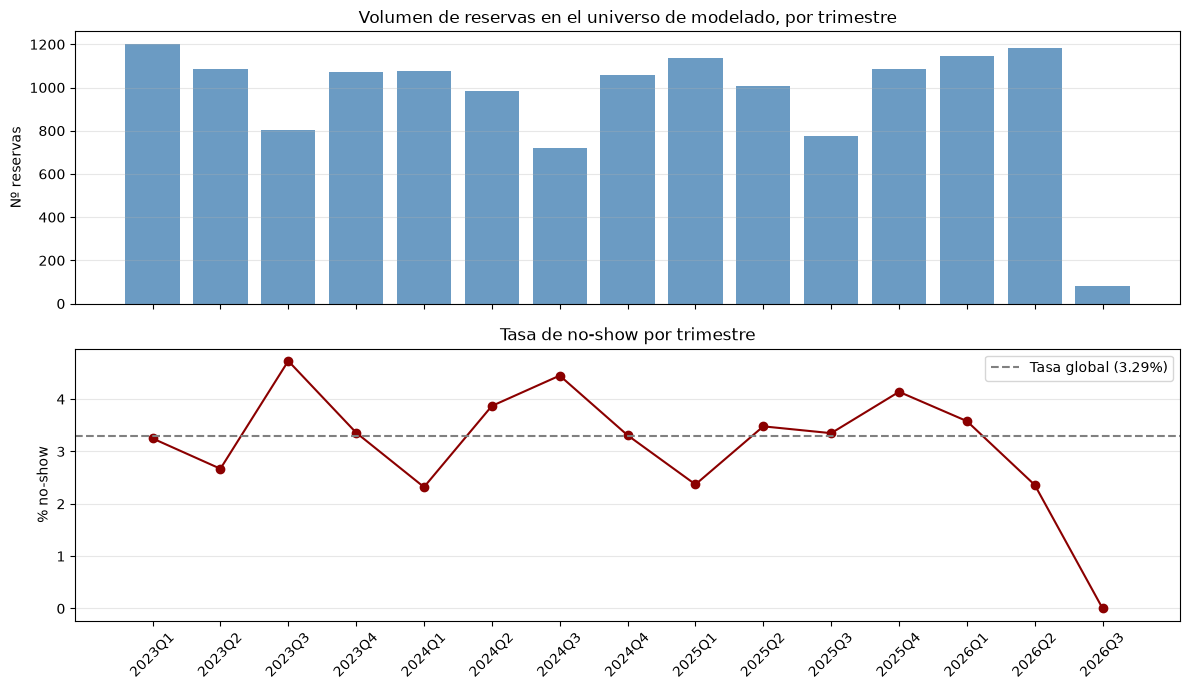

In [5]:
universo['periodo'] = universo['reservation_date'].dt.to_period('Q')

evolucion_noshow = (
    universo
    .groupby('periodo')
    .agg(
        n_total=('es_no_show', 'count'),
        n_no_show=('es_no_show', 'sum'),
    )
)
evolucion_noshow['tasa_no_show'] = (evolucion_noshow['n_no_show'] / evolucion_noshow['n_total'] * 100).round(2)

print("Evolución trimestral de la tasa de no-show:")
print(evolucion_noshow.to_string())
print()
print(f"Tasa global de referencia: {universo['es_no_show'].mean()*100:.2f}%")
print(f"Desviación estándar entre trimestres: {evolucion_noshow['tasa_no_show'].std():.2f} pp")

# Aviso si algún trimestre tiene muy pocos casos — la tasa en ese trimestre
# no es fiable aunque se aleje mucho de la media global
trimestres_pocos_casos = evolucion_noshow[evolucion_noshow['n_total'] < 100]
if len(trimestres_pocos_casos) > 0:
    print(f"\n⚠️  Trimestres con menos de 100 reservas (tasa poco fiable, no interpretar como cambio de régimen):")
    print(trimestres_pocos_casos.to_string())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

x = evolucion_noshow.index.astype(str)

axes[0].bar(x, evolucion_noshow['n_total'], color='steelblue', alpha=0.8)
axes[0].set_title('Volumen de reservas en el universo de modelado, por trimestre')
axes[0].set_ylabel('Nº reservas')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(x, evolucion_noshow['tasa_no_show'], marker='o', color='darkred', linewidth=1.5)
axes[1].axhline(universo['es_no_show'].mean()*100, color='grey', linestyle='--',
                label=f'Tasa global ({universo["es_no_show"].mean()*100:.2f}%)')
axes[1].set_title('Tasa de no-show por trimestre')
axes[1].set_ylabel('% no-show')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'noshow_evolucion_trimestral.png', dpi=150, bbox_inches='tight')
plt.show()

universo = universo.drop(columns='periodo')

El split cronológico es seguro, no hay un punto de corte temporal donde el comportamiento de no-show cambie de naturaleza.

El 2026Q3 con 0.00% no es una señal, es un artefacto de fin de dataset. El histórico termina el 2026-07-08, así que ese trimestre solo tiene 8 días de julio (83 reservas - ningún no-show)

### 3. Selección de variables

Se construyen las features en tres bloques, siguiendo la auditoría de disponibilidad temporal ya cerrada (momento de predicción: día del servicio):

- **Bloque A**: atributos propios de la reserva individual.
- **Bloque B.1**: contexto de calendario y meteorología del día.
- **Bloque B.2**: contexto de eventos locales del día.

In [6]:
print("=== ZONE ===")
print(f"Nulos: {universo['zone'].isna().mean()*100:.2f}%")
print(f"Valores únicos: {universo['zone'].nunique()}")
print(universo['zone'].value_counts().head(10))
print()

print("=== GROUP ===")
print(f"Nulos: {universo['group'].isna().mean()*100:.2f}%")
print(f"Valores únicos: {universo['group'].nunique()}")
print(universo['group'].value_counts().head(10))
print()

# Verificación cruzada: ¿'zone' varía con 'shift' o es prácticamente fija?
# Si 'zone' rota por turno (ej. terraza solo en cena) puede ser información
# de calendario, no de asignación real de mesa.
print("Distribución de zone por shift (%):")
print(pd.crosstab(universo['shift'], universo['zone'], normalize='index').round(3) * 100)

=== ZONE ===
Nulos: 0.05%
Valores únicos: 2
zone
Sala                10265
Terraza Cubierta     4147
Name: count, dtype: int64

=== GROUP ===
Nulos: 0.00%
Valores únicos: 2
group
NO    14404
SI       15
Name: count, dtype: int64

Distribución de zone por shift (%):
zone    Sala  Terraza Cubierta
shift                         
Cena    70.6              29.4
Comida  71.8              28.2


`group` se excluye por dos motivos: (1) su significado no está documentado
en ningún punto del pipeline (Bronze/Silver), y (2) con solo 15 casos de
`SI` sobre 14.419 filas (0.1%), no hay volumen suficiente para que el
modelo aprenda un patrón fiable, incluso si el significado fuera relevante.

`table` se excluye por no poder verificarse su disponibilidad antes del
momento de predicción (ver limitación de datos ya documentada). De forma
adicional, cabe señalar que, al ser una asignación operativa no visible
ni decidida por el cliente, es plausible que aporte menos señal
predictiva que otras variables de la reserva (`origin`, `zone`, `people`)
que sí reflejan características observables del proceso de reserva.
Esta es una consideración secundaria de interpretabilidad, no el motivo
de la exclusión, que sigue siendo la imposibilidad de verificar su
disponibilidad temporal.

#### 3.1 Bloque A — features de la reserva individual

Disponibles sin ambigüedad desde el momento de creación de la reserva: `shift`, `people`, `es_grupo_grande`, `origin`, `zone`, `antelacion_horas`.

In [7]:
features_reserva = universo[[
    'shift', 'people', 'es_grupo_grande', 'origin', 'zone',
    'antelacion_horas', 'es_no_show', 'reservation_date'
]].copy()

print(f"Shape: {features_reserva.shape}")
print(f"Nulos por columna:")
print(features_reserva.isna().sum())

Shape: (14419, 8)
Nulos por columna:
shift               0
people              0
es_grupo_grande     0
origin              0
zone                7
antelacion_horas    0
es_no_show          0
reservation_date    0
dtype: int64


#### 3.2 Bloque B.1 — calendario y meteorología

Se une por `reservation_date` directamente contra Silver (no contra Gold): `festivos_silver` y `meteo_diaria_silver` ya cubren el histórico completo desde 2023-01-01, igual que el universo de modelado, así que no hay hueco de cobertura que gestionar en este bloque (a diferencia de eventos, más abajo).

In [8]:
# contexto de calendario/meteo, unido desde Silver directamente para cubrir todo el histórico de reservas, no solo el período operativo con ventas.
festivos_silver = pd.read_parquet(SILVER_SNAP / 'festivos_silver.parquet')
meteo_silver = pd.read_parquet(SILVER_SNAP / 'meteo_diaria_silver.parquet')

festivos_por_fecha = festivos_silver[['fecha', 'es_festivo']].drop_duplicates(subset='fecha')

features_reserva = features_reserva.merge(
    festivos_por_fecha, left_on='reservation_date', right_on='fecha', how='left'
).drop(columns='fecha')
features_reserva['es_festivo'] = features_reserva['es_festivo'].fillna(0).astype(int)

features_reserva = features_reserva.merge(
    meteo_silver[['date', 'temperature_mean', 'precipitation_mm']],
    left_on='reservation_date', right_on='date', how='left'
).drop(columns='date')

print(f"Nulos tras el join de meteo/festivo: {features_reserva[['es_festivo', 'temperature_mean', 'precipitation_mm']].isna().sum()}")

Nulos tras el join de meteo/festivo: es_festivo          0
temperature_mean    0
precipitation_mm    0
dtype: int64


#### 3.3 Bloque B.2 — eventos locales

**El problema de partida:** `eventos_silver` tiene una fila por evento, con `fecha_inicio`/`fecha_fin` (un rango), no una fila por día. Para poder cruzarlo por fecha exacta contra `reservation_date`, primero hay que convertir esa tabla de rangos en una tabla de días sueltos — un proceso que llamamos **expandir**: por cada evento, se genera una fila por cada día que cubre su rango.

**Por qué no se expande todo junto.** Al medir la duración de los 48 eventos, se detectó que 8 de ellos no son eventos puntuales sino **temporadas** (vacaciones escolares de verano: 78 días; campañas comerciales de Navidad; periodo de comuniones...). Mezclar "un concierto un día concreto" con "78 días de verano" bajo la misma variable no es coherente, así que se separan **por duración, con corte en 14 días** (percentil 75 de toda la tabla: 5.75 días — hay un salto limpio hasta el mínimo del grupo largo, 15 días, sin casos intermedios que compliquen el corte).

**Qué se hace con cada grupo:**
- **Eventos de temporada (>14 días, 8 casos)**: se **excluyen** del modelo. Ver justificación completa más abajo.
- **Eventos puntuales (≤14 días, 40 casos)**: se expanden a nivel diario (celda siguiente).

**El problema que aparece al expandir los puntuales:** algunos días tienen más de un evento a la vez (18 días detectados — p. ej. el 5-sep-2026 tiene tres eventos solapados con intensidades 3, 2 y 2). Como al final se necesita una única fila por fecha, hay que decidir qué intensidad asignar a un día con varios eventos.

**La regla de agregación elegida:** la intensidad del evento **dominante** del día (el de mayor valor absoluto, conservando el signo — la escala tiene signo: positivo aumenta demanda esperada, negativo la reduce), más una variable aparte `n_eventos_dia` que cuenta cuántos eventos coincidieron ese día. Se descartó sumar las intensidades (3+2+2=7 sería un valor que ningún evento individual alcanza nunca, inventando una magnitud sin respaldo en los datos).

**Eventos de temporada (>14 días) excluidos del modelo, sin sustituto.**
Se excluyen los 8 eventos de duración superior a 14 días (campañas
comerciales de Navidad, vacaciones escolares de verano y Navidad,
temporada de comuniones, periodo de menor afluencia de agosto). De
estos, 6 cruzan entre 2 y 4 meses naturales, por lo que `mes` no
sustituye completamente la información que aportarían (p. ej., el
inicio de las vacaciones de verano a mitad de junio). Se acepta esta
pérdida de información por relación coste-beneficio: resolver
correctamente la intensidad con signo y los solapamientos múltiples
(hasta 3 eventos simultáneos en diciembre 2025-enero 2026) exige un
esfuerzo no trivial para una señal que ya se ha mostrado débil en el
modelo de facturación (Spearman 0.229) y de relevancia no verificada
para no-shows. Queda como limitación reconocida del modelo, no como
trabajo pendiente.

In [10]:
eventos_silver = pd.read_parquet(SILVER_SNAP / 'eventos_silver.parquet')
eventos_silver['duracion_dias'] = (
    eventos_silver['fecha_fin'] - eventos_silver['fecha_inicio']
).dt.days

# ── Eventos puntuales: expansión a nivel diario ─────────────────────────────
eventos_puntuales = eventos_silver[eventos_silver['duracion_dias'] <= 14].copy()

filas_expandidas = []
for _, row in eventos_puntuales.iterrows():
    for fecha in pd.date_range(row['fecha_inicio'], row['fecha_fin']):
        filas_expandidas.append({
            'fecha': fecha,
            'intensidad': row['intensidad_sugerida'],
            'nombre_evento': row['nombre_evento']
        })
eventos_diario = pd.DataFrame(filas_expandidas)

solapados = eventos_diario.groupby('fecha').size()
dias_con_solape = solapados[solapados > 1]
print(f"Días con más de un evento puntual solapado: {len(dias_con_solape)}")

# Salvaguarda: si el CSV de eventos cambia en el futuro y aparece un empate
# en |intensidad| con signos distintos, la regla de "evento dominante" deja
# de ser determinista (idxmax() elegiría según el orden del DataFrame, no
# por ningún criterio de negocio). Verificado sin empates en la versión
# actual (ver justificación); se deja como assert para que cualquier
# regeneración futura del dataset lo vuelva a comprobar automáticamente.
empates = eventos_diario.groupby('fecha')['intensidad'].apply(
    lambda g: (g.abs() == g.abs().max()).sum() > 1 and g.nunique() > 1
)
assert empates.sum() == 0, (
    f"{empates.sum()} días con empate en |intensidad| — revisar antes de "
    "confiar en la agregación por evento dominante (no sería determinista)."
)

# ── Agregación por día: evento dominante (máximo en valor absoluto, con ────
#    signo) + conteo de eventos simultáneos ─────────────────────────────────
def intensidad_dominante(grupo):
    return grupo.loc[grupo.abs().idxmax()]

intensidad_agregada = (
    eventos_diario
    .groupby('fecha')['intensidad']
    .apply(intensidad_dominante)
    .rename('intensidad_evento')
)

n_eventos_dia = (
    eventos_diario
    .groupby('fecha')
    .size()
    .rename('n_eventos_dia')
)

eventos_diario_agregado = pd.concat([intensidad_agregada, n_eventos_dia], axis=1).reset_index()
eventos_diario_agregado['tiene_evento'] = 1

print(f"Días con al menos un evento puntual: {len(eventos_diario_agregado)}")
eventos_diario_agregado.head()

Días con más de un evento puntual solapado: 18
Días con al menos un evento puntual: 99


,fecha,intensidad_evento,n_eventos_dia,tiene_evento
0,2025-10-10,2,1,1
1,2025-10-11,2,1,1
2,2025-10-12,2,1,1
3,2025-10-13,2,1,1
4,2025-10-19,2,1,1


**Unión final:** como `eventos_silver` solo cubre desde 2025-10-10 (conocimiento experto no reconstruible retroactivamente), se añade un indicador `tiene_cobertura_eventos` para distinguir "no hubo evento" (0, dentro de cobertura) de "no se sabe si hubo evento" (NaN, fuera de cobertura) — mismo criterio ya aplicado al hueco de Gold al principio del proyecto.

In [11]:
features_reserva = features_reserva.merge(
    eventos_diario_agregado, left_on='reservation_date', right_on='fecha', how='left'
).drop(columns='fecha')

features_reserva['tiene_cobertura_eventos'] = features_reserva['tiene_evento'].notna().astype(int)

features_reserva['tiene_evento'] = features_reserva['tiene_evento'].fillna(0)
features_reserva['n_eventos_dia'] = features_reserva['n_eventos_dia'].fillna(0)
# intensidad_evento se deja en NaN fuera de cobertura, no en 0 

In [12]:
print(f"Shape final de features_reserva: {features_reserva.shape}")
print(f"\nNulos por columna:")
print(features_reserva.isna().sum())
print(f"\nCobertura de eventos: {features_reserva['tiene_cobertura_eventos'].mean()*100:.1f}% "
      f"de las reservas caen dentro del rango de eventos_silver (oct-2025 en adelante)")

Shape final de features_reserva: (14419, 15)

Nulos por columna:
shift                          0
people                         0
es_grupo_grande                0
origin                         0
zone                           7
antelacion_horas               0
es_no_show                     0
reservation_date               0
es_festivo                     0
temperature_mean               0
precipitation_mm               0
intensidad_evento          13303
n_eventos_dia                  0
tiene_evento                   0
tiene_cobertura_eventos        0
dtype: int64

Cobertura de eventos: 7.7% de las reservas caen dentro del rango de eventos_silver (oct-2025 en adelante)


#### 3.4 Bloque C — volumen de reservas el mismo día y turno

**Hipótesis:** un día/turno con mucho volumen podría implicar menos margen de
seguimiento por parte del personal, o atraer un perfil de reserva distinto.

**Riesgo de auto-conteo:** si se cuenta el total de reservas de ese día/turno
sin excluir la propia fila, cada reserva se contaría a sí misma dentro de
su propio feature (la misma reserva "explicándose" con su propia presencia).
Se excluye explícitamente restando 1.

**Limitación reconocida:** se calcula sobre `universo` (completada + no_show,
sin walk-in), no sobre el total de reservas creadas ese día/turno. Esto
subestima el volumen real si hubo cancelaciones ese día — se acepta la
limitación por consistencia con la población ya usada en todo el modelo,
y por evitar el riesgo de leakage de incluir walk-in (conocido solo en
tiempo real, no antes del momento de predicción).

In [14]:
conteo_dia_turno = (
    universo
    .groupby(['reservation_date', 'shift'])
    .size()
    .rename('n_dia_turno')
    .reset_index()
)

features_reserva = features_reserva.merge(
    conteo_dia_turno, on=['reservation_date', 'shift'], how='left'
)
features_reserva['reservas_mismo_dia_turno'] = features_reserva['n_dia_turno'] - 1
features_reserva = features_reserva.drop(columns='n_dia_turno')

print(f"Nulos tras el cálculo: {features_reserva['reservas_mismo_dia_turno'].isna().sum()}")
print(f"Mínimo: {features_reserva['reservas_mismo_dia_turno'].min()}")
print(f"Máximo: {features_reserva['reservas_mismo_dia_turno'].max()}")
print(f"Media: {features_reserva['reservas_mismo_dia_turno'].mean():.1f}")

# Misma verificación de antes, ahora debería pasar sin fallo
fecha_test, turno_test = universo.iloc[0][['reservation_date', 'shift']]
total_dia_turno = ((universo['reservation_date'] == fecha_test) &
                    (universo['shift'] == turno_test)).sum()
valor_feature = features_reserva[
    (features_reserva['reservation_date'] == fecha_test) &
    (features_reserva['shift'] == turno_test)
]['reservas_mismo_dia_turno'].iloc[0]
assert valor_feature == total_dia_turno - 1, (
    f"Fallo de auto-exclusión: total={total_dia_turno}, feature={valor_feature}"
)
print(f"\n✓ Verificación de auto-exclusión correcta para {fecha_test.date()} ({turno_test})")

Nulos tras el cálculo: 0
Mínimo: 0
Máximo: 23
Media: 9.8

✓ Verificación de auto-exclusión correcta para 2023-02-19 (Comida)


### 4. Imputacion de nulos

**Imputación de `zone` (7 nulos, 0.05%).** Se imputa con la moda (`Sala`,
71% de las reservas) en lugar de una estrategia aleatoria proporcional o
de categoría "desconocido", dado el volumen ínfimo de casos afectados —
cualquier tratamiento es estadísticamente indistinguible a esta escala,
y la moda es la opción más simple y estándar para este caso.


In [15]:
moda_zone = universo['zone'].mode()[0]
print(f"Moda de zone: {moda_zone}")

n_nulos_antes = features_reserva['zone'].isna().sum()
features_reserva['zone'] = features_reserva['zone'].fillna(moda_zone)

print(f"Nulos imputados: {n_nulos_antes}")
print(f"Nulos restantes en zone: {features_reserva['zone'].isna().sum()}")

Moda de zone: Sala
Nulos imputados: 7
Nulos restantes en zone: 0


### 5. Split en train/test

In [16]:
features_reserva = features_reserva.sort_values('reservation_date').reset_index(drop=True)

FECHA_CORTE = features_reserva['reservation_date'].quantile(0.8)
print(f"Fecha de corte propuesta (percentil 80 cronológico): {FECHA_CORTE.date()}")

train = features_reserva[features_reserva['reservation_date'] < FECHA_CORTE].copy()
test = features_reserva[features_reserva['reservation_date'] >= FECHA_CORTE].copy()

print(f"\nTrain: {len(train)} filas ({train['reservation_date'].min().date()} → {train['reservation_date'].max().date()})")
print(f"  no-shows en train: {train['es_no_show'].sum()} ({train['es_no_show'].mean()*100:.2f}%)")

print(f"\nTest:  {len(test)} filas ({test['reservation_date'].min().date()} → {test['reservation_date'].max().date()})")
print(f"  no-shows en test:  {test['es_no_show'].sum()} ({test['es_no_show'].mean()*100:.2f}%)")

print(f"\nCobertura de eventos en train: {train['tiene_cobertura_eventos'].mean()*100:.1f}%")
print(f"Cobertura de eventos en test:  {test['tiene_cobertura_eventos'].mean()*100:.1f}%")

Fecha de corte propuesta (percentil 80 cronológico): 2025-11-25

Train: 11530 filas (2023-01-01 → 2025-11-23)
  no-shows en train: 390 (3.38%)

Test:  2889 filas (2025-11-25 → 2026-07-08)
  no-shows en test:  84 (2.91%)

Cobertura de eventos en train: 1.2%
Cobertura de eventos en test:  34.0%


#### Limitación: exposición de entrenamiento mínima en las variables de eventos

El split cronológico (corte en 2025-11-25) deja una asimetría severa en la
cobertura de `eventos_silver` entre train y test:

| Partición | Cobertura de eventos |
|---|---|
| Train (2023-01-01 → 2025-11-23) | 1.2% (~138 de 11.530 filas) |
| Test (2025-11-25 → 2026-07-08) | 34.0% (~982 de 2.889 filas) |

Esta asimetría es consecuencia directa de que `eventos_silver` solo cubre
desde 2025-10-10 (conocimiento experto no reconstruible retroactivamente,
ver limitación ya documentada en el EDA), combinada con que el split
cronológico necesariamente deja la mayor parte del histórico antiguo en
train.

**Consecuencia práctica**: con solo ~138 filas de entrenamiento donde
`tiene_evento`/`intensidad_evento`/`n_eventos_dia` tienen valor informado
(el resto queda en `NaN` por falta de cobertura, ya gestionado con el
indicador `tiene_cobertura_eventos`), el modelo dispone de muy poca
señal para aprender un patrón fiable sobre estas variables — mientras que
en test se le va a pedir que generalice sobre un conjunto donde sí están
informadas en un tercio de los casos.

**Decisión**: se acepta esta limitación sin ajustar el split ni excluir
las variables de eventos del modelo (moverlas o quitarlas no resuelve el
problema estructural de cobertura de la fuente, solo lo redistribuye o
descarta información real para el subconjunto de test donde sí existe).
La importancia que el modelo asigne a las variables de eventos en la
evaluación final debe interpretarse con esta cautela explícita: una baja
o nula importancia puede deberse tanto a que la señal no es relevante
como a que el modelo no tuvo suficiente exposición en entrenamiento para
aprenderla, y ambas explicaciones son indistinguibles con los datos
disponibles.